In [2]:
import matplotlib.pyplot as plt
import torch 
import torch.nn.functional as f
char_dim=24
bloc_size=8
nb_ite=10000
hidden_layer=100
batch_size=32
vocab_size=27
lr=0.1

In [3]:
words=open("names.txt",'r').read().splitlines()
index_chars={i+1:chr(i+ord("a")) for i in range (26)}
index_chars[0]='.'
chars_index={i:s for s,i in index_chars.items()}
def build_data(words,bloc_size):
    X,Y=[],[]
    for w in words:
        sample=[0]*bloc_size
        for ch in w + ".":
            ix=chars_index[ch]
            X.append(sample)
            Y.append(ix)
            sample=sample[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return(X,Y)
import random 
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_data(words[:n1],bloc_size)
Xdev,Ydev=build_data(words[n1:n2],bloc_size)
Xte,Yte=build_data(words[n2:],bloc_size)

In [4]:
g = torch.Generator().manual_seed(2147483647)
class Linear:
    def __init__(self,n_input,n_output,bias=True):
        self.weight=torch.randn((n_input,n_output),generator=g)/n_input**0.5
        if bias==True:
            self.bias=torch.zeros(n_output)
        else:
            self.bias=None
    def __call__(self,x_input):
        self.out=x_input@self.weight
        if self.bias != None:
            self.out+=self.bias
        return(self.out)
    def parameters(self):
        if self.bias==None:
            return([self.weight])
        else:
            return([self.weight]+[self.bias])
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1,train=True):
        self.eps=eps
        self.momentum=momentum
        self.training=train
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)
    def __call__(self,x):
        if self.training:
            if x.ndim==3:
                xmean=x.mean((0,1),keepdim=True)
                xvar=x.var((0,1),keepdim=True)
            elif x.ndim==2:
                xmean=x.mean(0,keepdim=True)
                xvar=x.var(0,keepdim=True)
        else:
            xmean=self.running_mean
            xvar=self.running_var
        x_norm=(x-xmean)/((xvar+self.eps)**0.5)
        self.out=self.gamma*x_norm+self.beta
        if self.training==True:
            self.running_mean=self.running_mean*(1-self.momentum)+xmean*self.momentum
            self.running_var=self.running_var*(1-self.momentum)+xvar*self.momentum
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]
class Tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out
    def parameters(self):
        return []
class Embedding:
    def __init__(self,vocab_size,dim):
        self.weight=torch.randn(vocab_size,dim)
    def __call__(self,x):
        self.out= self.weight[x]
        return self.out
    def parameters(self):
        return [self.weight]
class My_Flatten:
    def __init__(self,n):
        self.n=n
    def __call__(self, emb):
        n=self.n
        X,Y,Z=emb.shape
        emb=emb.view(X,Y//n,Z*n)
        if emb.shape[1]==1:
            emb=emb.squeeze(1)
        self.out=emb
        return(self.out)
    def parameters(self):
        return []
class Sequential:
    def __init__(self,layers):
        self.layers=layers
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        self.out=x
        return self.out
    def parameters(self):
        return [p for layer in layers for p in layer.parameters()]

In [5]:
layers = [
  Embedding(vocab_size,char_dim),
  My_Flatten(2),
  Linear(char_dim * 2, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  My_Flatten(2),
  Linear(           hidden_layer*2, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  My_Flatten(2),  
  Linear(           hidden_layer*2, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  Linear(           hidden_layer, vocab_size, bias=False)
]
Seq=Sequential(layers)
for p in Seq.parameters():
    p.requires_grad=True

In [6]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre
lossi,stepi=[],[]
for i in range(nb_ite):
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    x,yb=Xtr[ix],Ytr[ix]
    x=Seq(x)
    loss=f.cross_entropy(x,yb)
    for p in Seq.parameters():
        p.grad=None
    loss.backward()    
    if i>nb_ite//2:
        lr=lr/10
    for p in Seq.parameters():
        p.data+=-lr*p.grad
    lossi.append(loss.log10().item())
    stepi.append(i)
    if i%1000==0:
        print(i,":",loss.item())

0 : 3.402848243713379
1000 : 2.565432548522949
2000 : 2.2049949169158936
3000 : 2.2207226753234863
4000 : 2.303091049194336
5000 : 2.102734088897705
6000 : 2.5029704570770264
7000 : 2.7397115230560303
8000 : 1.9518859386444092
9000 : 2.1427483558654785


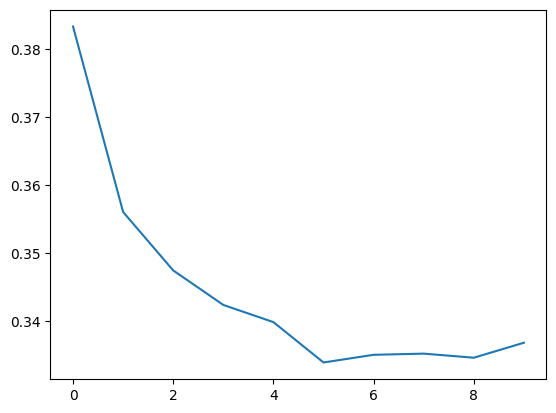

In [7]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [8]:
for layer in Seq.layers:
    layer.training=False

In [9]:
@torch.no_grad()
def loss_value(x,Y):
    x=Seq(x)
    loss=f.cross_entropy(x,Y)
    return(loss)
L=[("train",Xtr,Ytr),("dev",Xdev,Ydev),("test",Xte,Yte)]
for item in L:
    print ("{} loss=".format(item[0]),loss_value(item[1],item[2]))

train loss= tensor(2.1557)
dev loss= tensor(2.1763)
test loss= tensor(2.1687)


In [10]:
for _ in range(42):    
    out = []
    context = [0] * bloc_size 
    while True:
        x=torch.tensor([context])
        x=Seq(x)
        probs = f.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join([index_chars[i] for i in out]))

rama.
tlara.
kaykin.
quiana.
quord.
khorrish.
verin.
skiyah.
zanaily.
aunora.
glodan.
slyan.
keeman.
briley.
rarlynn.
berrendqu.
layinni.
maari.
jhananve.
coldwana.
elunekia.
kemell.
novr.
ramari.
gaadilen.
milial.
pella.
torellam.
dega.
kian.
manson.
niseiwan.
maraula.
talisd.
neson.
azlee.
tyan.
azylynn.
kaszyel.
zasten.
golliah.
restanis.
